In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("default of credit card clients.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (30001, 25)


In [3]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0



Column names:
['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(30001, 25)

Data Types:
Unnamed: 0    str
X1            str
X2            str
X3            str
X4            str
X5            str
X6            str
X7            str
X8            str
X9            str
X10           str
X11           str
X12           str
X13           str
X14           str
X15           str
X16           str
X17           str
X18           str
X19           str
X20           str
X21           str
X22           str
X23           str
Y             str
dtype: object

Missing Values:
Unnamed: 0    0
X1            0
X2            0
X3            0
X4            0
X5            0
X6            0
X7            0
X8            0
X9            0
X10           0
X11           0
X12           0
X13           0
X14           0
X15           0
X16           0
X17           0
X18           0
X19           0
X20           0
X21           0
X22           0
X23           0
Y             0
dtype: int64

Duplicate Rows:
0


In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


In [9]:
# Remove the extra header row
df = df[df["Y"] != "default payment next month"].copy()

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Check the result
print("Shape:", df.shape)
print("\nTarget values:")
print(df["Y"].value_counts())

Shape: (30000, 24)

Target values:
Y
0    23364
1     6636
Name: count, dtype: int64


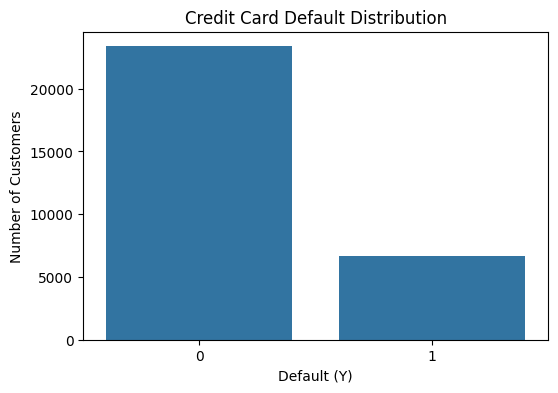

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["Y"])

plt.title("Credit Card Default Distribution")
plt.xlabel("Default (Y)")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
print("Descriptive Statistics:")
display(df.describe().T)

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [12]:
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing)

print("\nTotal missing values:", missing.sum())

Missing values in each column:
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

Total missing values: 0


In [13]:
# Check outliers using the IQR method

Q1 = df.drop(columns=["Y"]).quantile(0.25)
Q3 = df.drop(columns=["Y"]).quantile(0.75)

IQR = Q3 - Q1

outliers = ((df.drop(columns=["Y"]) < (Q1 - 1.5 * IQR)) |
            (df.drop(columns=["Y"]) > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers in each feature:")
print(outliers)

Number of outliers in each feature:
X1      167
X2        0
X3      454
X4        0
X5      272
X6     3130
X7     4410
X8     4209
X9     3508
X10    2968
X11    3079
X12    2400
X13    2395
X14    2469
X15    2622
X16    2725
X17    2693
X18    2745
X19    2714
X20    2598
X21    2994
X22    2945
X23    2958
dtype: int64


In [14]:
# Continuous features where outlier treatment is appropriate
continuous_features = [
    "X1", "X5",
    "X12", "X13", "X14", "X15", "X16", "X17",
    "X18", "X19", "X20", "X21", "X22", "X23"
]

# Cap extreme values at 1st and 99th percentiles
for col in continuous_features:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier treatment completed using 1st–99th percentile capping.")

Outlier treatment completed using 1st–99th percentile capping.


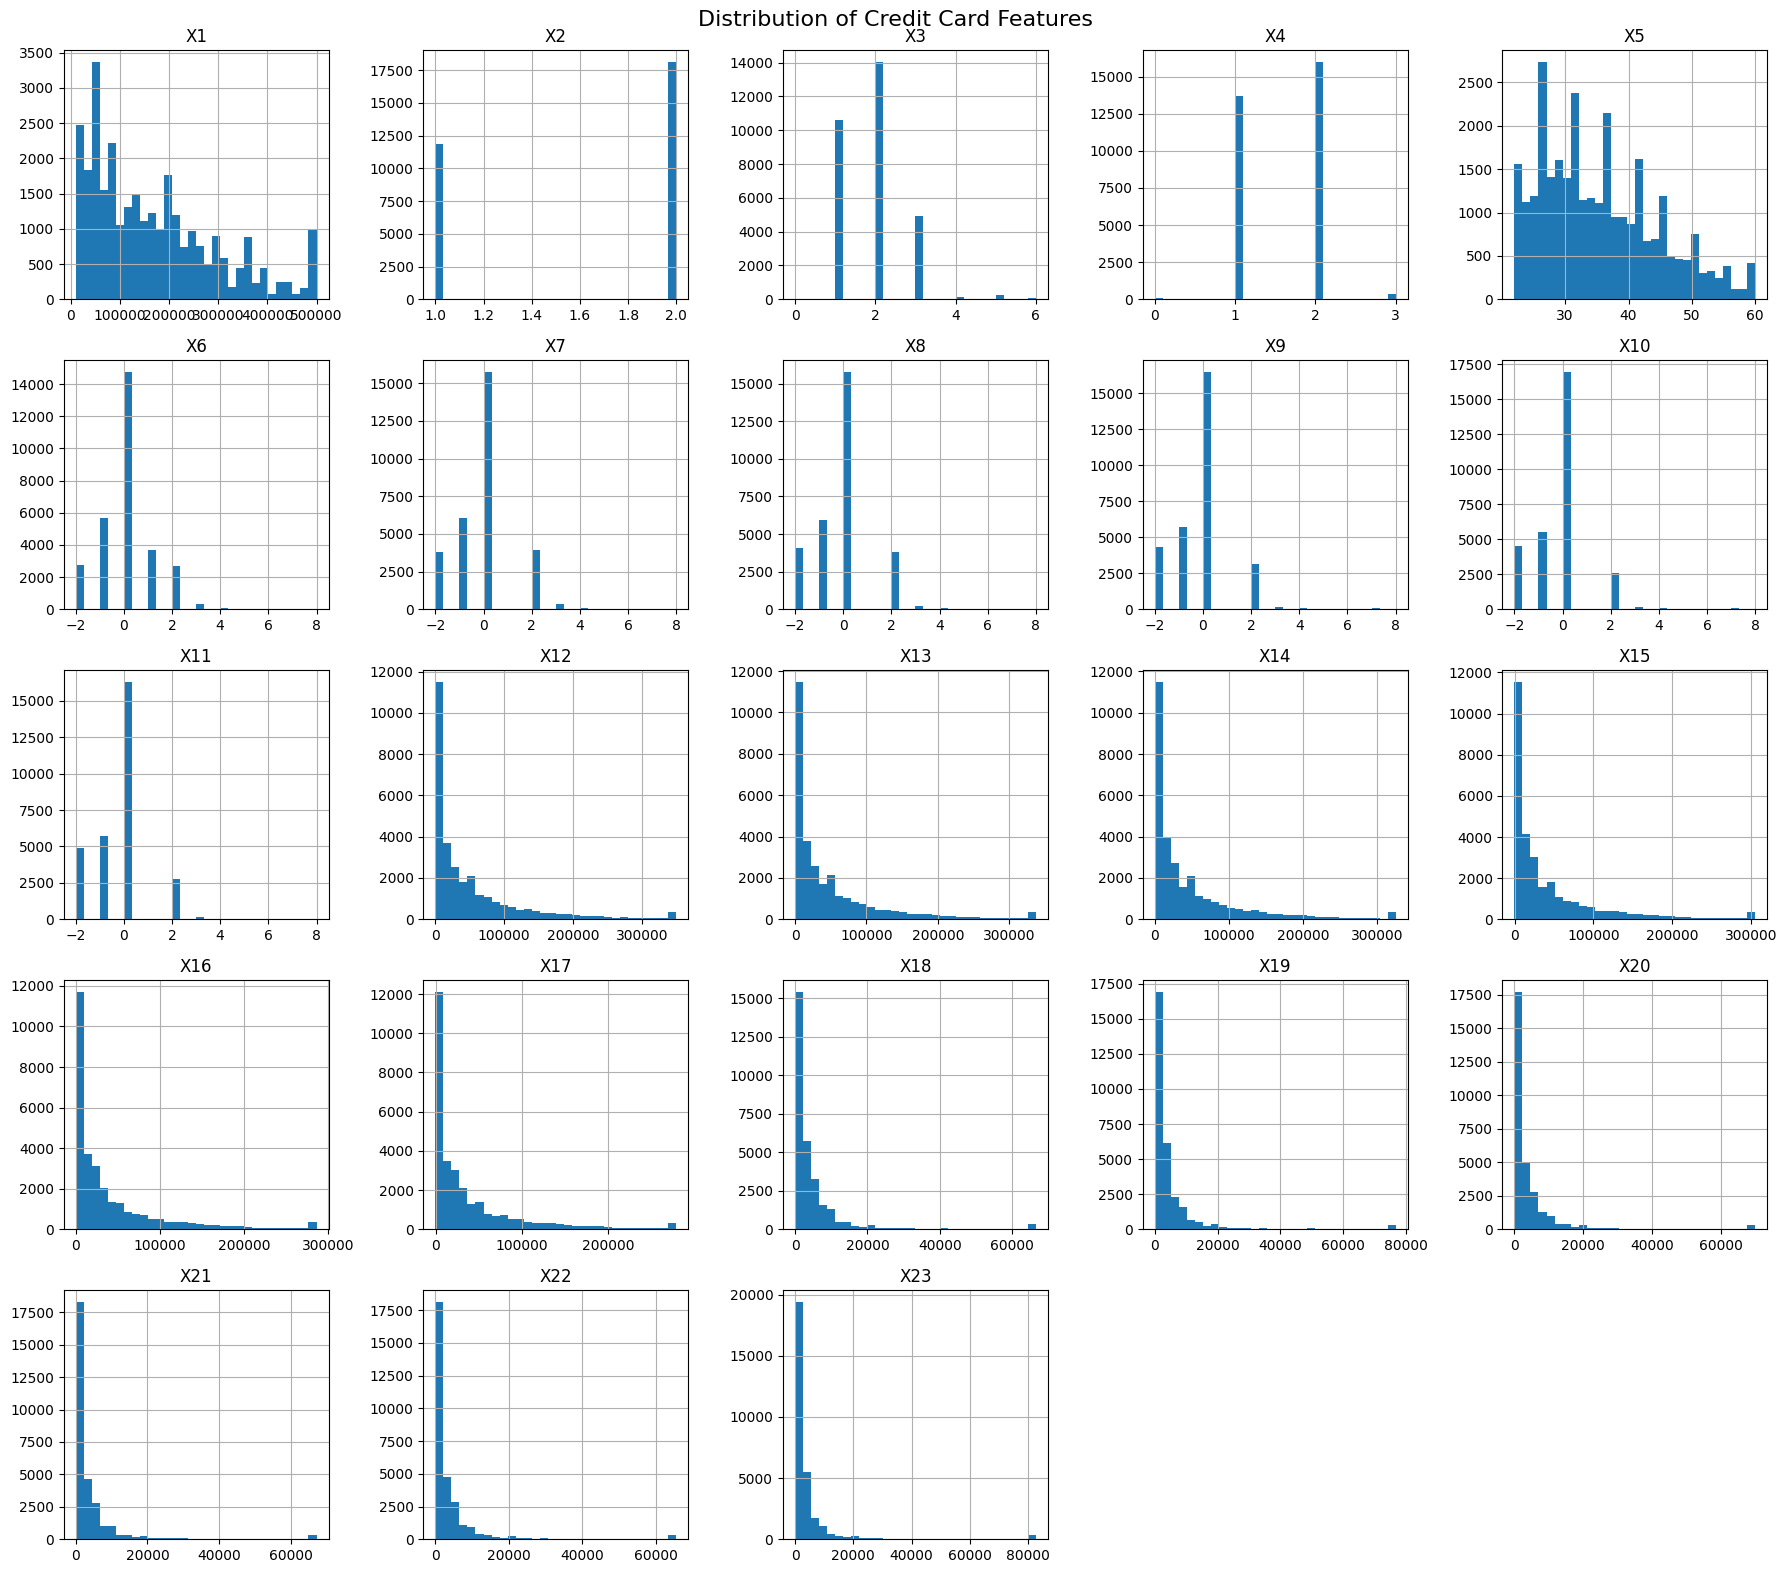

In [15]:
# Distribution of numerical features

features = df.drop(columns=["Y"]).columns

df[features].hist(
    figsize=(18, 16),
    bins=30
)

plt.suptitle("Distribution of Credit Card Features", fontsize=16)
plt.tight_layout()
plt.show()

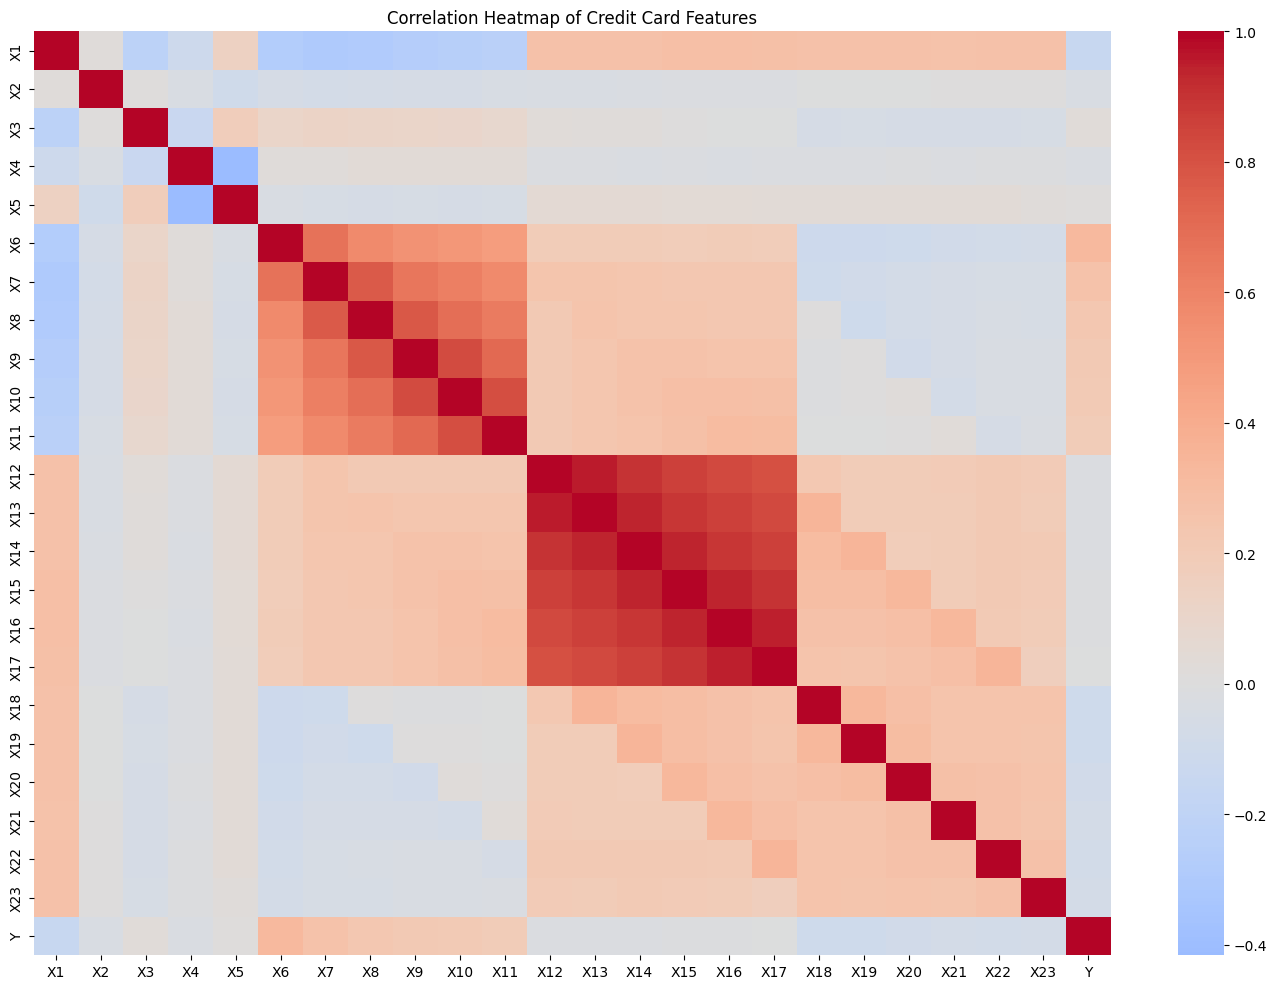

In [16]:
plt.figure(figsize=(14, 10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Credit Card Features")
plt.tight_layout()
plt.show()

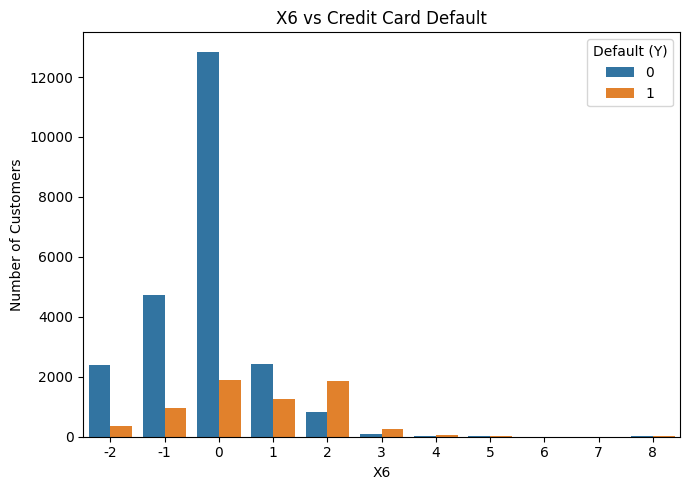

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="X6", hue="Y")

plt.title("X6 vs Credit Card Default")
plt.xlabel("X6")
plt.ylabel("Number of Customers")
plt.legend(title="Default (Y)")

plt.tight_layout()
plt.show()

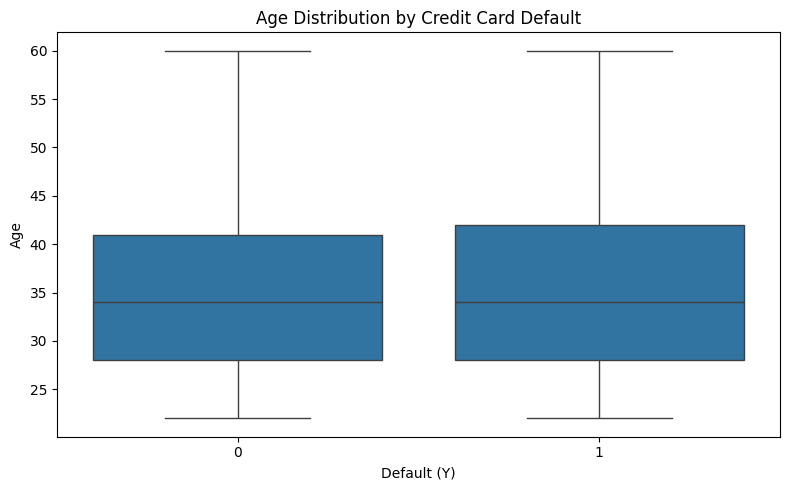

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Y", y="X5")

plt.title("Age Distribution by Credit Card Default")
plt.xlabel("Default (Y)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [19]:
# Feature Engineering

bill_features = ["X12", "X13", "X14", "X15", "X16", "X17"]
payment_features = ["X18", "X19", "X20", "X21", "X22", "X23"]

df["Avg_Bill_Amount"] = df[bill_features].mean(axis=1)
df["Avg_Payment_Amount"] = df[payment_features].mean(axis=1)

print("New features created successfully!")
print("\nNew columns:")
print(df[["Avg_Bill_Amount", "Avg_Payment_Amount"]].head())

New features created successfully!

New columns:
   Avg_Bill_Amount  Avg_Payment_Amount
1      1284.000000          114.833333
2      2846.166667          833.333333
3     16942.166667         1836.333333
4     38555.666667         1398.000000
5     18223.166667         9841.500000


In [20]:
# Separate input features and target

X = df.drop(columns=["Y"])
y = df["Y"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Features shape: (30000, 25)
Target shape: (30000,)

Training set: (24000, 25)
Testing set: (6000, 25)

Training target distribution:
Y
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Testing target distribution:
Y
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [21]:
# Feature Scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling completed successfully!
X_train_scaled shape: (24000, 25)
X_test_scaled shape: (6000, 25)


In [22]:
# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Weighted F1-score:", f1_score(y_test, y_pred_lr, average="weighted"))

Logistic Regression completed!
Accuracy: 0.808
Weighted F1-score: 0.7696443662804912


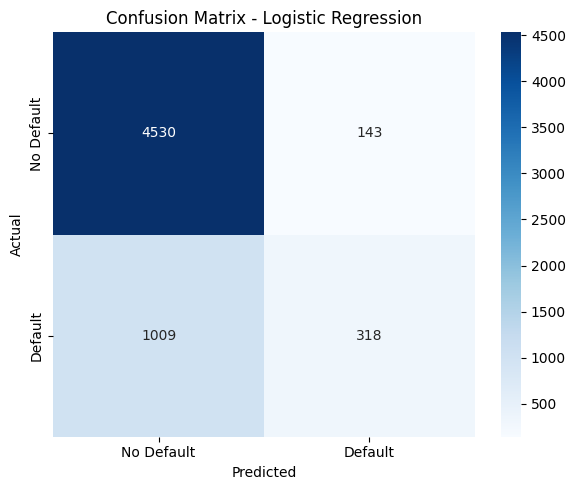

In [23]:
# Confusion Matrix - Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [24]:
# KNN Classifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Weighted F1-score:", f1_score(y_test, y_pred_knn, average="weighted"))

KNN completed!
Accuracy: 0.7965
Weighted F1-score: 0.7789576702728018


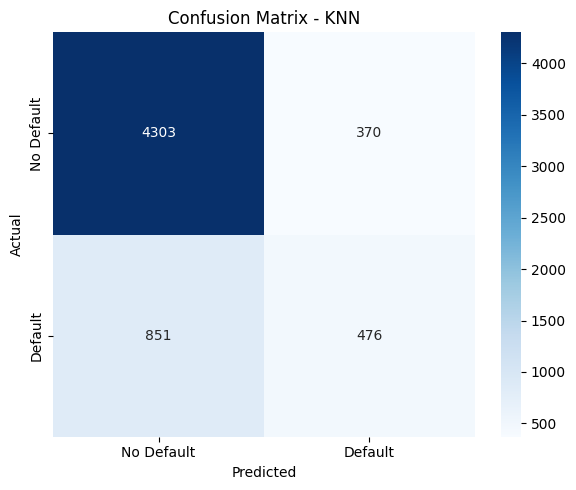

In [25]:
# Confusion Matrix - KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [26]:
# Gaussian Naive Bayes

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Gaussian Naive Bayes completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Weighted F1-score:", f1_score(y_test, y_pred_nb, average="weighted"))

Gaussian Naive Bayes completed!
Accuracy: 0.6345
Weighted F1-score: 0.6651160753861584


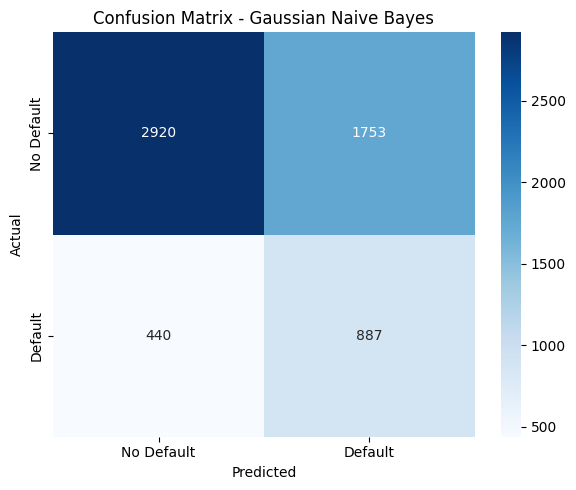

In [27]:
# Confusion Matrix - Gaussian Naive Bayes

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [28]:
# Decision Tree Classifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Weighted F1-score:", f1_score(y_test, y_pred_dt, average="weighted"))

Decision Tree completed!
Accuracy: 0.7216666666666667
Weighted F1-score: 0.7246740600720828


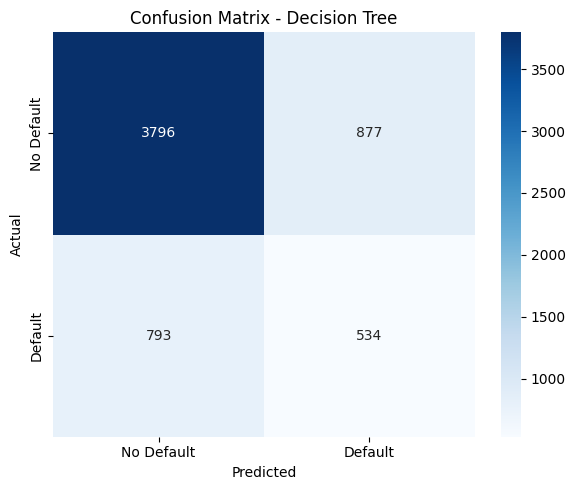

In [29]:
# Confusion Matrix - Decision Tree

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [31]:
# Support Vector Machine (SVM)

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM completed!")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Weighted F1-score:", f1_score(y_test, y_pred_svm, average="weighted"))

SVM completed!
Accuracy: 0.815
Weighted F1-score: 0.7904844886448272


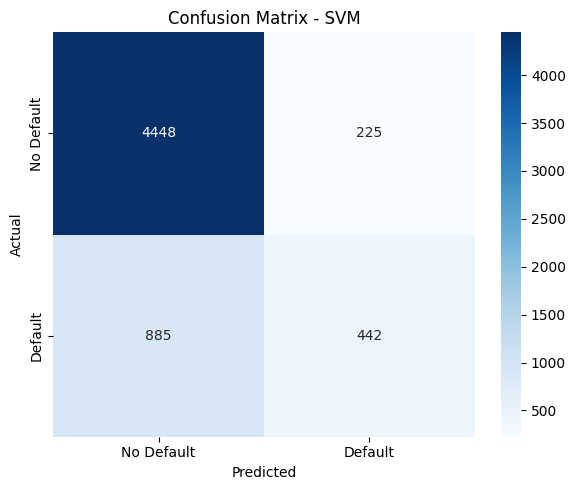

In [32]:
# Confusion Matrix - SVM

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [33]:
# Comparison of Classification Part-A Models

results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "KNN",
        "Gaussian Naive Bayes",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Weighted F1-Score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_knn, average="weighted"),
        f1_score(y_test, y_pred_nb, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ]
})

display(results.sort_values(by="Weighted F1-Score", ascending=False))

,Algorithm,Accuracy,Weighted F1-Score
4,SVM,0.815000,0.790484
1,KNN,0.796500,0.778958
0,Logistic Regression,0.808000,0.769644
3,Decision Tree,0.721667,0.724674
2,Gaussian Naive Bayes,0.634500,0.665116


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Cross-validation for SVM
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", random_state=42))
])

svm_cv = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("SVM 5-Fold Cross-Validation")
print("Scores:", svm_cv)
print("Mean Accuracy:", svm_cv.mean())
print("Standard Deviation:", svm_cv.std())

SVM 5-Fold Cross-Validation
Scores: [0.81645833 0.82208333 0.81770833 0.82270833 0.81854167]
Mean Accuracy: 0.8195
Standard Deviation: 0.0024636242498491134


In [36]:
# Cross-validation for KNN

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_cv = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("KNN 5-Fold Cross-Validation")
print("Scores:", knn_cv)
print("Mean Accuracy:", knn_cv.mean())
print("Standard Deviation:", knn_cv.std())

KNN 5-Fold Cross-Validation
Scores: [0.79375    0.795625   0.78770833 0.78958333 0.7975    ]
Mean Accuracy: 0.7928333333333333
Standard Deviation: 0.0036671401209480217


In [37]:
# Final Classification Part-A Results

final_results = results.copy()

# Add 5-fold CV mean accuracy
cv_means = {
    "SVM": svm_cv.mean(),
    "KNN": knn_cv.mean()
}

final_results["5-Fold CV Accuracy"] = final_results["Algorithm"].map(cv_means)

final_results = final_results.sort_values(
    by="Weighted F1-Score",
    ascending=False
)

display(final_results)

,Algorithm,Accuracy,Weighted F1-Score,5-Fold CV Accuracy
4,SVM,0.815000,0.790484,0.819500
1,KNN,0.796500,0.778958,0.792833
0,Logistic Regression,0.808000,0.769644,NaN
3,Decision Tree,0.721667,0.724674,NaN
2,Gaussian Naive Bayes,0.634500,0.665116,NaN


In [38]:
# Final Observations

best_model = final_results.iloc[0]["Algorithm"]

print("FINAL OBSERVATIONS")
print("------------------")

print(f"1. Among the five Part-A algorithms, {best_model} achieved the highest Weighted F1-score.")

print("2. SVM achieved an Accuracy of 81.50% and a Weighted F1-score of 0.7905.")

print("3. KNN achieved an Accuracy of 79.65% and a Weighted F1-score of 0.7790.")

print("4. Logistic Regression also showed good performance with 80.80% accuracy.")

print("5. Decision Tree and Gaussian Naive Bayes performed comparatively lower.")

print(f"6. SVM achieved a 5-fold cross-validation accuracy of {svm_cv.mean():.4f}.")

print(f"7. KNN achieved a 5-fold cross-validation accuracy of {knn_cv.mean():.4f}.")

print("8. Overall, SVM is the best-performing Part-A model for this dataset based on the obtained results.")

FINAL OBSERVATIONS
------------------
1. Among the five Part-A algorithms, SVM achieved the highest Weighted F1-score.
2. SVM achieved an Accuracy of 81.50% and a Weighted F1-score of 0.7905.
3. KNN achieved an Accuracy of 79.65% and a Weighted F1-score of 0.7790.
4. Logistic Regression also showed good performance with 80.80% accuracy.
5. Decision Tree and Gaussian Naive Bayes performed comparatively lower.
6. SVM achieved a 5-fold cross-validation accuracy of 0.8195.
7. KNN achieved a 5-fold cross-validation accuracy of 0.7928.
8. Overall, SVM is the best-performing Part-A model for this dataset based on the obtained results.
